# House price prediction - Forward and Backward propagation

Implement a **single-layer neural network from scratch** for house-price prediction.

The notebook follows the assignment requirements exactly:

1. Data Preprocessing
   - Load the dataset
   - Handle missing values
   - Encode categorical features
   - Normalize numerical features
2. Initialize Weights and Biases
3. Forward Propagation
   - Linear combination of inputs and weights
   - ReLU activation
4. Backward Propagation
   - Mean Squared Error (MSE)
   - Gradients with respect to weights and bias
5. Gradient Descent
   - Update weights and bias
6. Activation Functions
   - Compare **ReLU vs Tanh**
   - Plot loss curves
   - Plot gradient behavior

> This implementation uses NumPy so the forward pass, backward pass, gradients, and parameter updates are visible rather than hidden inside `model.fit()`.

In [204]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error


In [205]:
df = pd.read_csv('data\\house_price_prediction_dataset.csv')
df.head(5)

,Bedrooms,Bathrooms,Square Footage,House Age,Distance to City Center,Has Garage,Neighborhood Quality,Lot Size,Year Built,Number of Floors,House Price
0,4.0,3.0,1056.0,82.0,19.495982,1.0,Low,0.279486,2021.0,3.0,473533.294523
1,5.0,1.0,3587.0,71.0,19.159617,0.0,Medium,0.462426,1920.0,3.0,689385.695219
2,3.0,3.0,3766.0,33.0,16.647488,1.0,Medium,0.113631,1927.0,3.0,665609.060480
3,5.0,1.0,4067.0,1.0,0.440551,0.0,Medium,0.444495,1902.0,2.0,759245.467907
4,5.0,1.0,2556.0,26.0,20.925565,1.0,Low,0.727850,1913.0,2.0,677336.271454


In [206]:
df.shape

(3000, 11)

In [207]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Bedrooms                 2925 non-null   float64
 1   Bathrooms                2925 non-null   float64
 2   Square Footage           2925 non-null   float64
 3   House Age                2925 non-null   float64
 4   Distance to City Center  2925 non-null   float64
 5   Has Garage               2925 non-null   float64
 6   Neighborhood Quality     3000 non-null   str    
 7   Lot Size                 3000 non-null   float64
 8   Year Built               3000 non-null   float64
 9   Number of Floors         3000 non-null   float64
 10  House Price              3000 non-null   float64
dtypes: float64(10), str(1)
memory usage: 257.9 KB


# Descriptive Statistics

In [208]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Bedrooms,2925.0,3.012308,1.429075,1.000000,2.000000,3.000000,4.000000,5.000000
Bathrooms,2925.0,2.013333,0.822162,1.000000,1.000000,2.000000,3.000000,3.000000
Square Footage,2925.0,2754.796239,1291.463098,501.000000,1625.000000,2762.000000,3867.000000,4998.000000
House Age,2925.0,50.457778,29.033261,0.000000,25.000000,51.000000,76.000000,99.000000
Distance to City Center,2925.0,15.130816,8.607852,0.101580,7.724609,14.994077,22.677310,29.990229
Has Garage,2925.0,0.502222,0.500081,0.000000,0.000000,1.000000,1.000000,1.000000
Lot Size,3000.0,1.035687,0.544269,0.100333,0.561294,1.034935,1.491584,1.999420
Year Built,3000.0,1960.774000,35.895762,1900.000000,1930.000000,1960.000000,1992.000000,2023.000000
Number of Floors,3000.0,1.971000,0.822020,1.000000,1.000000,2.000000,3.000000,3.000000
House Price,3000.0,560533.966757,114912.699169,205437.077733,479685.029411,561967.188449,642643.494626,914436.352270


# Numerical and House Price Distribution

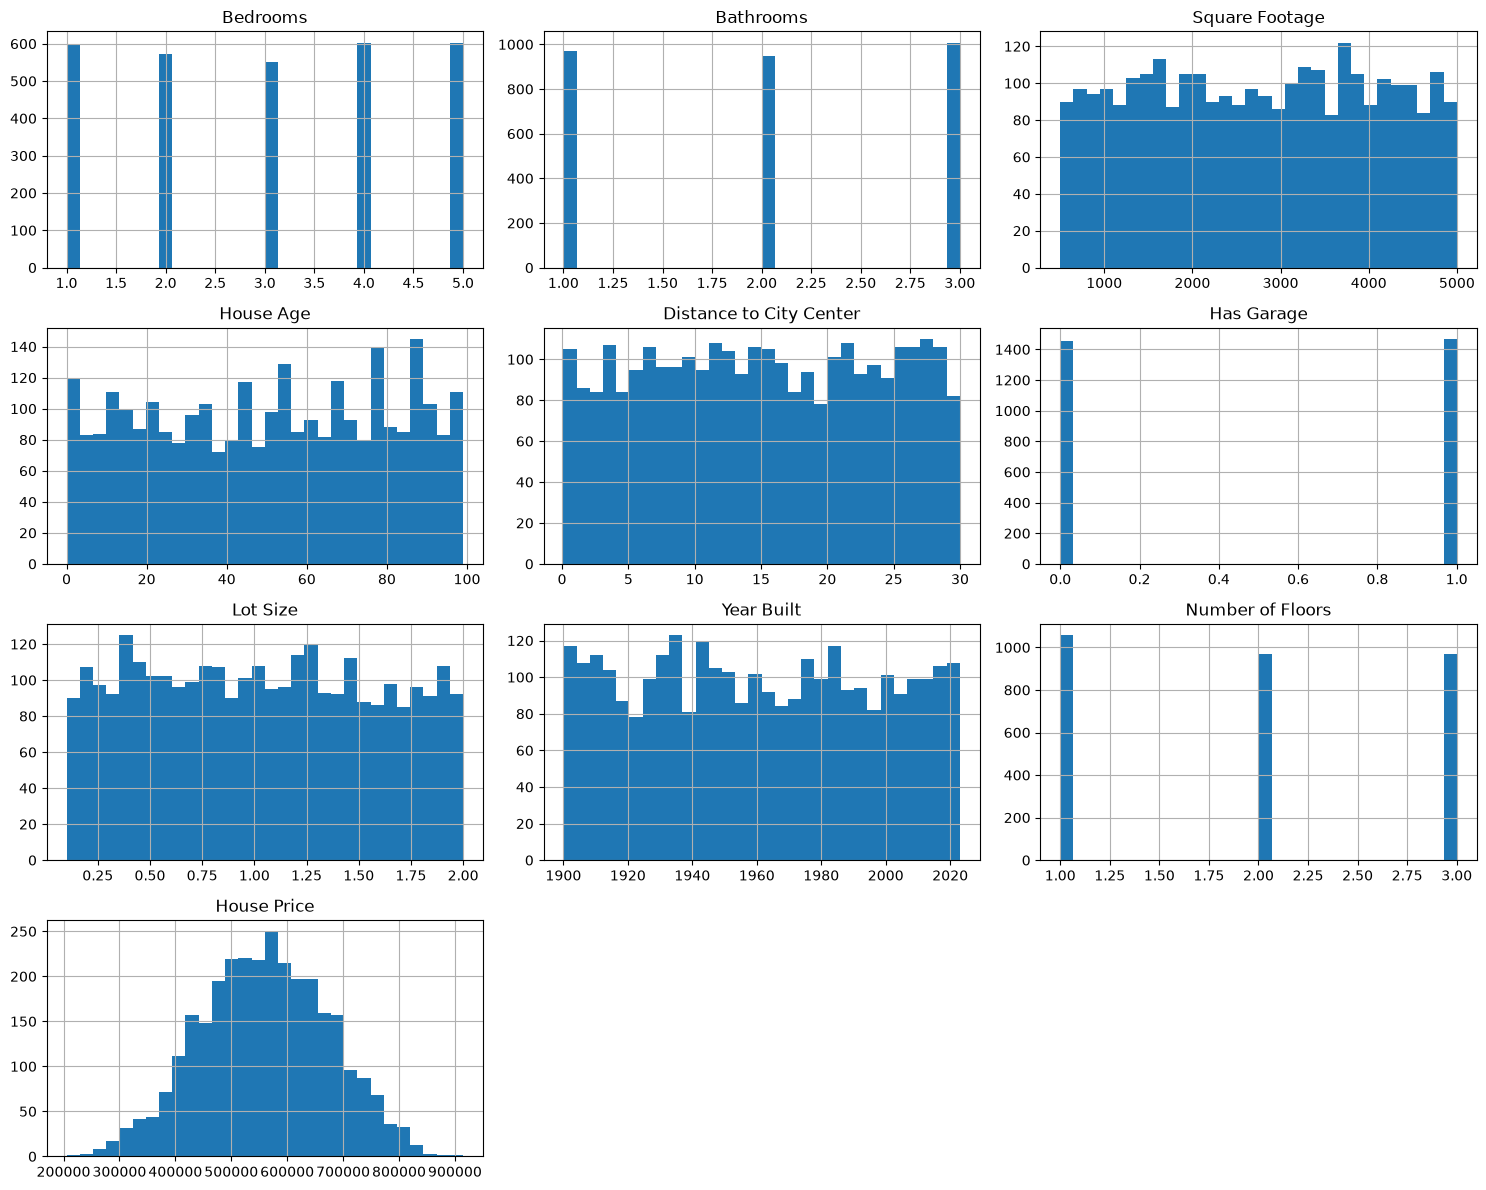

In [209]:
df.hist(figsize=(15, 12),bins=30)

plt.tight_layout()
plt.show()

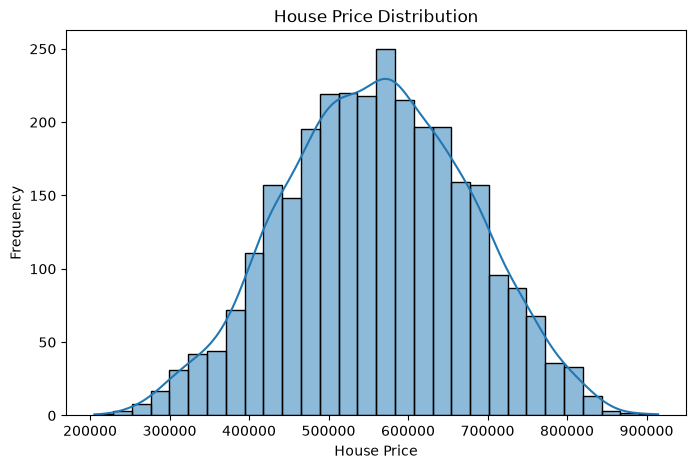

In [210]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["House Price"],
    bins=30,
    kde=True
)

plt.title("House Price Distribution")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

# Correlation Heatmap

In [211]:
corr = df.corr(numeric_only=True)
print(corr["House Price"].sort_values(ascending=False))

House Price                1.000000
Bedrooms                   0.626696
Square Footage             0.555263
Bathrooms                  0.188646
Number of Floors           0.152725
Has Garage                 0.076304
Lot Size                   0.050639
Distance to City Center   -0.069643
Year Built                -0.145706
House Age                 -0.271745
Name: House Price, dtype: float64


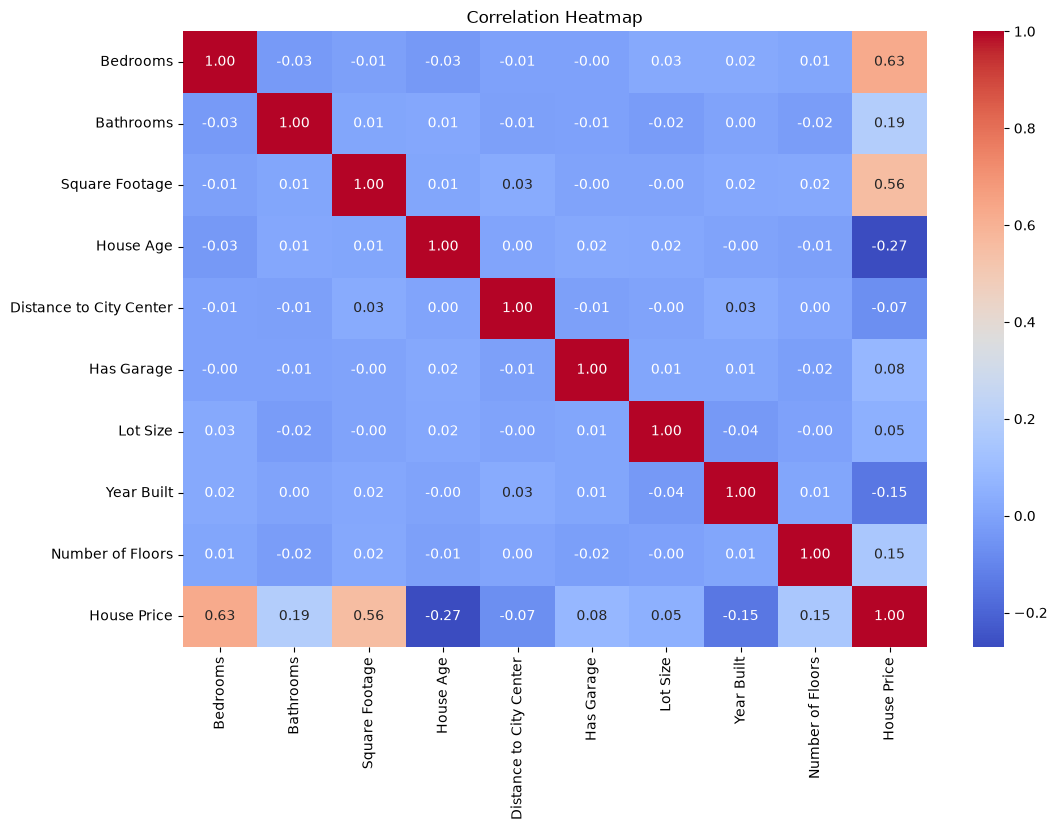

In [212]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# House Age and House Price

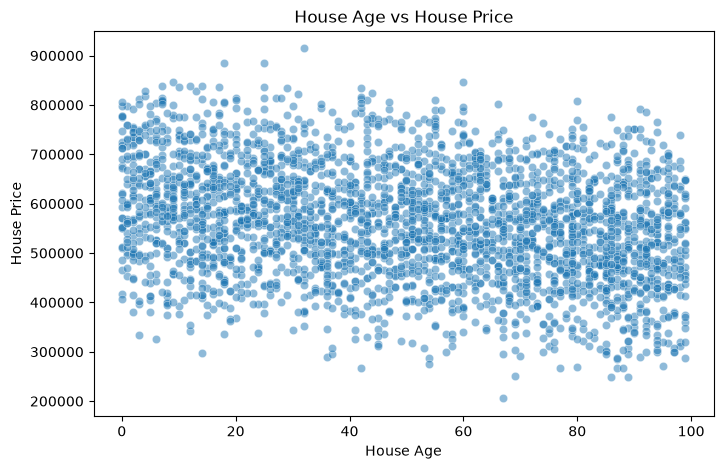

In [213]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='House Age', y='House Price', alpha= 0.5)
plt.title('House Age vs House Price')
plt.xlabel('House Age')
plt.ylabel('House Price')
plt.show()

# Data Preparation

### Separate Feature and Target

* x = Feature
* y = Target

In [214]:
X = df.drop('House Price', axis = 1).copy()
y = df['House Price'].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (3000, 10)
y shape: (3000,)


# Train/Test Split

In [215]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state= 42
)
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (2400, 10)
X_test : (600, 10)
y_train: (2400,)
y_test : (600,)


# Impute Missing Numeric Vlaues 

Checking for the missing values

In [216]:
missing = pd.DataFrame({
  'missingCount': df.isna().sum(),
  'missingPercent': df.isna().mean()*100
})

print(missing)

                         missingCount  missingPercent
Bedrooms                           75             2.5
Bathrooms                          75             2.5
Square Footage                     75             2.5
House Age                          75             2.5
Distance to City Center            75             2.5
Has Garage                         75             2.5
Neighborhood Quality                0             0.0
Lot Size                            0             0.0
Year Built                          0             0.0
Number of Floors                    0             0.0
House Price                         0             0.0


In [217]:
df.isna().sum()[df.isna().sum()>0]

Bedrooms                   75
Bathrooms                  75
Square Footage             75
House Age                  75
Distance to City Center    75
Has Garage                 75
dtype: int64

In [218]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Bedrooms                 2925 non-null   float64
 1   Bathrooms                2925 non-null   float64
 2   Square Footage           2925 non-null   float64
 3   House Age                2925 non-null   float64
 4   Distance to City Center  2925 non-null   float64
 5   Has Garage               2925 non-null   float64
 6   Neighborhood Quality     3000 non-null   str    
 7   Lot Size                 3000 non-null   float64
 8   Year Built               3000 non-null   float64
 9   Number of Floors         3000 non-null   float64
 10  House Price              3000 non-null   float64
dtypes: float64(10), str(1)
memory usage: 257.9 KB


In [219]:
numeric_col=[
    'Bedrooms', 
    'Bathrooms', 
    'Square Footage', 
    'House Age',
    'Distance to City Center', 
    'Has Garage'
]

for col in numeric_col:
    median_val = X_train[col].median()
    X_train.loc[:,col] = X_train[col].fillna(median_val)
    X_test.loc[:,col] = X_test[col].fillna(median_val)   


In [220]:
#Has Garage is in binary indicator..
garage_mode = X_train['Has Garage'].mode()[0]
X_train.loc[:,'Has Garage']= X_train['Has Garage'].fillna(garage_mode)
X_test.loc[:,'Has Garage']= X_test['Has Garage'].fillna(garage_mode)


In [221]:
print(X_train.isna().sum(), '\n-------------')
print(X_test.isna().sum())

Bedrooms                   0
Bathrooms                  0
Square Footage             0
House Age                  0
Distance to City Center    0
Has Garage                 0
Neighborhood Quality       0
Lot Size                   0
Year Built                 0
Number of Floors           0
dtype: int64 
-------------
Bedrooms                   0
Bathrooms                  0
Square Footage             0
House Age                  0
Distance to City Center    0
Has Garage                 0
Neighborhood Quality       0
Lot Size                   0
Year Built                 0
Number of Floors           0
dtype: int64


# One hot encoding

In [222]:
df['Neighborhood Quality'].unique()

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [223]:
X_train = pd.get_dummies(
    X_train,
    columns = ['Neighborhood Quality'],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns = ['Neighborhood Quality'],
    drop_first=True,
    dtype=int
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [224]:
df.duplicated().sum()

np.int64(0)

# Normalization

### Standardize Input Features

In [225]:
scaler_X = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc = scaler_X.transform(X_test)

print(X_train_sc.shape)
print(X_test_sc.shape)

(2400, 11)
(600, 11)


### Scale the Target

In [226]:
scaler_y = MinMaxScaler()

y_train_sc = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()

y_test_sc = scaler_y.transform(y_test.to_numpy().reshape(-1,1)).ravel()

# Initialize Weight and Bias

In [227]:
np.random.seed(42)

n_feature = X_train_sc.shape[1]
W = np.random.randn(n_feature)*0.01
b = 0.0

print(n_feature)
print(W.shape)
print(b)

11
(11,)
0.0


# Activation Function

### ReLU

In [228]:
def relu(z):
    return np.maximum(0,z)

def relu_derivative(z):
    return (z>0).astype(float)    

### Tanh

In [229]:
def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    a = np.tanh(z)
    return 1 - a**2

# Forward Propagation

In [230]:
def forward_propagation(X, W, b, activation= 'relu'):
    #z = np.dot(X,W)+b
    z = X @ W + b


    if activation == 'relu':
        y_pred = relu(z)
    elif activation == 'tanh':
        y_pred = tanh(z)
    else:
        raise ValueError('activation should be relu or tanh ') 

    return z, y_pred       

In [231]:
#`MSE = mean(|y_true - y_pred|^2)`

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def mse_grad(y_true, y_pred):
    n = len(y_true)
    return (2/n) * (y_pred - y_true)

# Backward Propagation

In [232]:
def backward_propagation(X, y_true, y_pred, z, activation):
    dL_dy_pred = mse_grad(y_true, y_pred)

    if activation == "relu":
        dy_dz = relu_derivative(z)
    elif activation == "tanh":
        dy_dz = tanh_derivative(z)
    else:
        raise ValueError("activation should be 'relu' or 'tanh'")

    #dL/dz = dL/dy_pred × dy_pred/dz
    dL_dz = dL_dy_pred * dy_dz

    #dW = np.dot(X.T, dL_dz)
    dW = X.T @ dL_dz
    db = np.sum(dL_dz)

    return dW, db

# Gradient Descent

In [233]:
def train_model(X, y, activation="relu", epochs=2000, learning_rate=0.01):
    np.random.seed(42)

    n_features = X.shape[1]

    W = np.random.randn(n_features) * 0.01
    b = 0.0

    loss_history = []
    gradient_history = []

    for epoch in range(epochs):

        # Forward propagation
        z, y_pred = forward_propagation(X, W, b, activation)

        # Calculate Loss
        loss = mse_loss(y, y_pred)
        loss_history.append(loss)

        # Backward propagation
        dW, db = backward_propagation(X, y, y_pred, z, activation)

        # Store gradient magnitude
        gradient_history.append(np.linalg.norm(dW))

        # Gradient descent update
        W -= learning_rate * dW
        b -= learning_rate * db

    return W, b, loss_history, gradient_history

## Train ReLU model

In [234]:
W_relu, b_relu, loss_relu, grad_relu = train_model(
    X_train_sc,
    y_train_sc,
    activation="relu",
    epochs=2000,
    learning_rate=0.01
)

print("ReLU training completed")
print("Final ReLU MSE:", loss_relu[-1])

ReLU training completed
Final ReLU MSE: 0.0018711386112575201


## Train Tanh model

In [235]:
W_tanh, b_tanh, loss_tanh, grad_tanh = train_model(
    X_train_sc,
    y_train_sc,
    activation="tanh",
    epochs=2000,
    learning_rate=0.01
)

print("Tanh training complete")
print("Final training loss:", loss_tanh[-1])


Tanh training complete
Final training loss: 0.002405839243350989


# Loss Curve

### ReLU vs Tanh

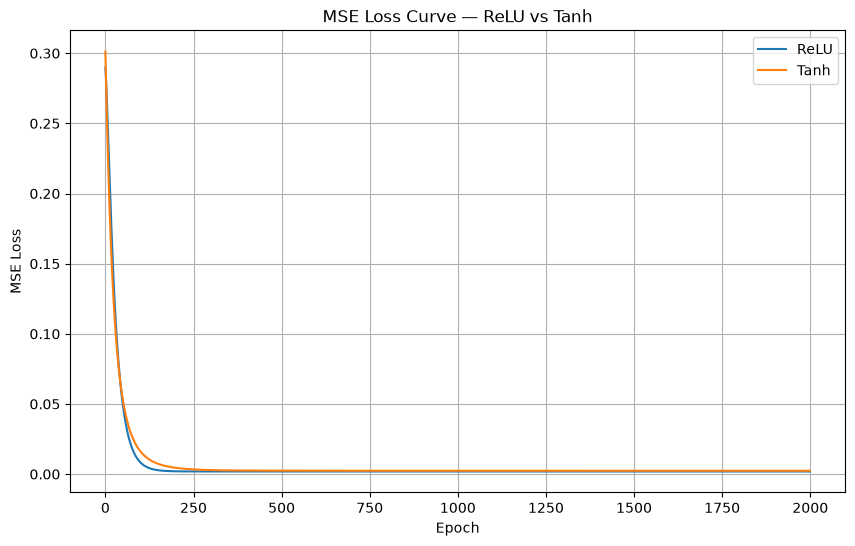

In [236]:
plt.figure(figsize=(10, 6))

plt.plot(loss_relu, label="ReLU")
plt.plot(loss_tanh, label="Tanh")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MSE Loss Curve — ReLU vs Tanh")
plt.legend()
plt.grid(True)
plt.show()

## Observation
<pre>
-> ReLU didn't perfrom well
-> Tanh
</pre>

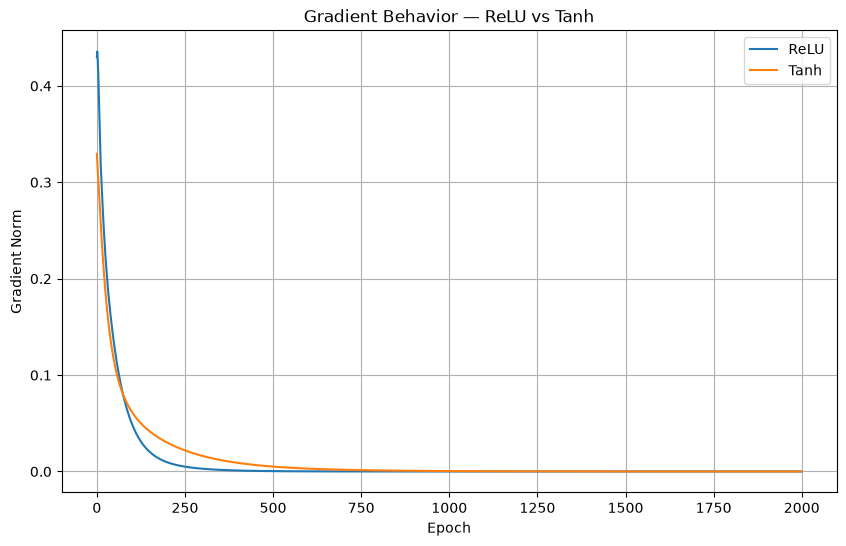

In [237]:
plt.figure(figsize=(10, 6))

plt.plot(grad_relu, label="ReLU")
plt.plot(grad_tanh, label="Tanh")

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("Gradient Behavior — ReLU vs Tanh")
plt.legend()
plt.grid(True)
plt.show()

## Observation
<pre>
-> Tanh performed well 
-> ReLU performed poorly
</pre>

In [238]:
# Test Prediction
_, pred_relu_scaled = forward_propagation(
    X_test_sc,
    W_relu,
    b_relu,
    activation="relu"
)

_, pred_tanh_scaled = forward_propagation(
    X_test_sc,
    W_tanh,
    b_tanh,
    activation="tanh"
)

In [239]:
# Convert Prediction Back to House Price Units

pred_relu = scaler_y.inverse_transform(
    pred_relu_scaled.reshape(-1, 1)
).ravel()

pred_tanh = scaler_y.inverse_transform(
    pred_tanh_scaled.reshape(-1, 1)
).ravel()

print("First 5 actual prices:")
print(y_test.to_numpy()[:5])

print("\nFirst 5 ReLU predictions:")
print(pred_relu[:5])

print("\nFirst 5 Tanh predictions:")
print(pred_tanh[:5])

First 5 actual prices:
[574086.13958985 588372.03377646 497364.50423147 527053.94720988
 641177.13985062]

First 5 ReLU predictions:
[607042.27441495 553004.79616153 499136.55444342 555509.6776146
 653658.39181874]

First 5 Tanh predictions:
[615207.67959126 565130.74204824 509585.19302105 568580.82432708
 653170.62985725]


In [240]:
# Test MSE

mse_relu = mean_squared_error(y_test, pred_relu)
mse_tanh = mean_squared_error(y_test, pred_tanh)

print(f"ReLU Test MSE : {mse_relu:,.2f}")
print(f"Tanh Test MSE : {mse_tanh:,.2f}")

ReLU Test MSE : 841,552,139.42
Tanh Test MSE : 1,117,663,201.05


# Compare ReLU and Tanh

In [241]:
comparison = pd.DataFrame({
    "Activation": ["ReLU", "Tanh"],
    "Final Training MSE": [loss_relu[-1], loss_tanh[-1]],
    "Test MSE": [mse_relu, mse_tanh],
    "Final Gradient Norm": [grad_relu[-1], grad_tanh[-1]]
})

comparison

,Activation,Final Training MSE,Test MSE,Final Gradient Norm
0,ReLU,0.001871,8.415521e+08,1.334942e-10
1,Tanh,0.002406,1.117663e+09,4.699721e-06


In [242]:
print("y_test    :", np.asarray(y_test).shape)
print("pred_relu :", np.asarray(pred_relu).shape)
print("pred_tanh :", np.asarray(pred_tanh).shape)

y_test    : (600,)
pred_relu : (600,)
pred_tanh : (600,)


Actual : (600,)
ReLU   : (600,)
Tanh   : (600,)


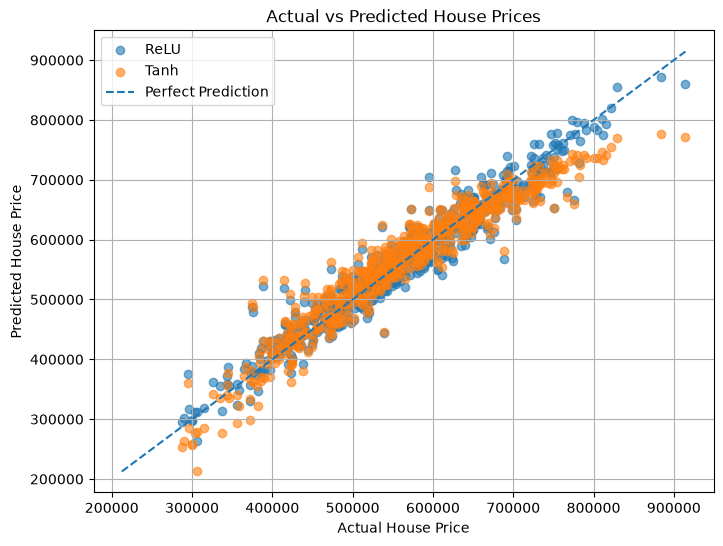

In [244]:


actual = np.asarray(y_test).ravel()
relu_pred = np.asarray(pred_relu).ravel()
tanh_pred = np.asarray(pred_tanh).ravel()

print("Actual :", actual.shape)
print("ReLU   :", relu_pred.shape)
print("Tanh   :", tanh_pred.shape)

plt.figure(figsize=(8, 6))

plt.scatter(actual, relu_pred, alpha=0.6, label="ReLU")
plt.scatter(actual, tanh_pred, alpha=0.6, label="Tanh")

min_value = min(
    actual.min(),
    relu_pred.min(),
    tanh_pred.min()
)

max_value = max(
    actual.max(),
    relu_pred.max(),
    tanh_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(True)

### ReLU

- Negative inputs produce zero output.
- Negative `z` values also produce zero activation gradient.
- Positive `z` values have derivative 1.

### Tanh

- Output is bounded between `-1` and `1`.
- Its gradient is largest around zero.
- Its gradient becomes small when the neuron saturates near `-1` or `1`.

### Performance
<pre>
ReLU = 0.001871
Tanh = 0.002406

So ReLU performed better than Tanh on the training data.
The difference is:

0.002406 - 0.001871 = 0.000535

So ReLU's final training MSE is about 22% lower than Tanh's.
</pre>

>The final training `MSE` was `0.001871` for `ReLU` and `0.002406` for `Tanh`. Since lower MSE indicates lower prediction error, `ReLU` achieved a better training fit than `Tanh`. The test results also show that ReLU performed better on unseen data.